# Results Figures
Generates all four figures needed for the Results section:
- **Figure 1**: Real data — 5 motion covariates and spikes plot
- **Figure 2**: Simulated data — per-cell model comparison boxplot
- **Figure 3**: Simulated data — TL architecture comparison boxplot
- **Figure 4**: Real data — full model comparison boxplot (100 cells)
- **Figure 5**: Pairwise scatter — best TL model vs GLM, coloured by batch

In [1]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# Add project root so src imports work
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.get_data import load_data
from src.visualisation import (
    plot_r2_comparison_boxplot,
    plot_covariate_trial,
    COVARIATE_NAMES_REAL,
    _set_journal_style,
)

# Output directory for all figures
FIG_DIR = Path("../resources/results/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")

Setup complete.


## 1. Load Simulated Data Results

In [2]:
SIM_MODEL_DIR = Path("../resources/models/simulated")

# Model names exactly as saved
SIM_PERCELL_MODELS = [
    "GLM",
    "XGBoost",
    "NN-PerCell-MLP",
    "NN-PerCell-CNN",
    "NN-PerCell-RNN",
]

SIM_TL_MODELS = [
    "NN-DeepSharedShallowHead-TL-MLP",
    "NN-DeepSharedShallowHead-TL-CNN",
    "NN-DeepSharedShallowHead-TL-RNN",
    "NN-DeepSharedDeepHead-TL-MLP",
    "NN-DeepSharedDeepHead-TL-CNN",
    "NN-DeepSharedDeepHead-TL-RNN",
    "NN-ShallowSharedDeepHead-TL-MLP",
    "NN-ShallowSharedDeepHead-TL-CNN",
    "NN-ShallowSharedDeepHead-TL-RNN",
]


def load_pkl(path):
    with open(path, "rb") as f:
        return pickle.load(f)


def load_sim_model(name):
    """Load a simulated model result dict, unwrapping the 'results' key."""
    pkl_path = SIM_MODEL_DIR / f"{name}.pkl"
    if not pkl_path.exists():
        print(f"  [SKIP] {name} — file not found")
        return None
    try:
        raw = load_pkl(pkl_path)

        # The pkl may be a list of (dict, name) tuples from run_experiment
        # or just the raw dict — handle both cases
        if isinstance(raw, list):
            # Take the first matching entry
            raw = raw[0][0] if isinstance(raw[0], tuple) else raw[0]

        # Unwrap the 'results' key if present
        if isinstance(raw, dict) and "results" in raw:
            results = raw["results"]
        else:
            results = raw

        # Normalise cell IDs to int (simulated uses floats: 0.0, 1.0, ...)
        results = {int(k): v for k, v in results.items()}

        return results
    except Exception as e:
        print(f"  [WARN] {name}: {e}")
        return None


print("Loading simulated per-cell models...")
sim_percell_list = []
for name in SIM_PERCELL_MODELS:
    res = load_sim_model(name)
    if res is not None:
        sim_percell_list.append((res, name))
        print(f"  Loaded {name}: {len(res)} cells")

print("\nLoading simulated TL models...")
sim_tl_list = []
for name in SIM_TL_MODELS:
    res = load_sim_model(name)
    if res is not None:
        sim_tl_list.append((res, name))
        print(f"  Loaded {name}: {len(res)} cells")

print(f"\nReady: {len(sim_percell_list)} per-cell, {len(sim_tl_list)} TL models")

Loading simulated per-cell models...
  Loaded GLM: 20 cells
  Loaded XGBoost: 20 cells
  Loaded NN-PerCell-MLP: 20 cells
  Loaded NN-PerCell-CNN: 20 cells
  Loaded NN-PerCell-RNN: 20 cells

Loading simulated TL models...
  Loaded NN-DeepSharedShallowHead-TL-MLP: 20 cells
  Loaded NN-DeepSharedShallowHead-TL-CNN: 20 cells
  Loaded NN-DeepSharedShallowHead-TL-RNN: 20 cells
  Loaded NN-DeepSharedDeepHead-TL-MLP: 20 cells
  Loaded NN-DeepSharedDeepHead-TL-CNN: 20 cells
  Loaded NN-DeepSharedDeepHead-TL-RNN: 20 cells
  Loaded NN-ShallowSharedDeepHead-TL-MLP: 20 cells
  Loaded NN-ShallowSharedDeepHead-TL-CNN: 20 cells
  Loaded NN-ShallowSharedDeepHead-TL-RNN: 20 cells

Ready: 5 per-cell, 9 TL models


## 2. Load Real Data Results from Combined CSV
Reconstructs the `model_results_list` format from the combined CSV,
avoiding the `src` module pickle issue.

In [3]:
REAL_RESULTS_DIR = Path("../resources/results/real/combined")
all_r2_path = REAL_RESULTS_DIR / "combined_batches_0_1_2_3_all_r2.csv"
df_all = pd.read_csv(all_r2_path)
print("Columns:", df_all.columns.tolist())
print("Shape:", df_all.shape)
df_all.head()

Columns: ['cell', 'GLM', 'NN-DeepSharedDeepHead-TL-CNN', 'NN-DeepSharedDeepHead-TL-MLP', 'NN-DeepSharedDeepHead-TL-RNN', 'NN-DeepSharedShallowHead-TL-CNN', 'NN-DeepSharedShallowHead-TL-MLP', 'NN-DeepSharedShallowHead-TL-RNN', 'NN-PerCell-CNN', 'NN-PerCell-MLP', 'NN-PerCell-RNN', 'NN-ShallowSharedDeepHead-TL-CNN', 'NN-ShallowSharedDeepHead-TL-MLP', 'NN-ShallowSharedDeepHead-TL-RNN', 'XGBoost']
Shape: (100, 15)


,cell,GLM,NN-DeepSharedDeepHead-TL-CNN,NN-DeepSharedDeepHead-TL-MLP,NN-DeepSharedDeepHead-TL-RNN,NN-DeepSharedShallowHead-TL-CNN,NN-DeepSharedShallowHead-TL-MLP,NN-DeepSharedShallowHead-TL-RNN,NN-PerCell-CNN,NN-PerCell-MLP,NN-PerCell-RNN,NN-ShallowSharedDeepHead-TL-CNN,NN-ShallowSharedDeepHead-TL-MLP,NN-ShallowSharedDeepHead-TL-RNN,XGBoost
0,1,-0.008305,0.092165,0.061126,0.018444,0.082151,0.009188,-0.005557,-0.079348,0.021697,-0.054452,0.008946,0.013549,0.026181,0.053484
1,2,0.121348,0.184275,0.199585,0.141035,0.186865,0.203070,0.137167,0.109085,0.186043,-0.009834,0.159723,0.199880,0.128892,0.177876
2,3,-0.085893,0.146991,0.162701,0.076718,0.129902,0.105139,0.038226,0.037189,0.084490,0.105782,0.077174,0.094248,0.072442,0.143645
3,4,-0.083061,0.204279,0.196657,0.175304,0.197938,0.167300,0.144160,0.058297,0.133414,0.169333,0.137264,0.176800,0.167885,0.152777
4,5,0.132449,0.265061,0.295984,0.204297,0.283374,0.280341,0.218374,-0.159784,0.177141,0.102195,0.235840,0.276670,0.185022,0.197943


In [4]:
def wide_csv_to_results_list(df, cell_col="cell", split="test"):
    model_cols = [c for c in df.columns if c != cell_col]
    results_list = []
    for model_name in model_cols:
        results_dict = {}
        for _, row in df.iterrows():
            cell = int(row[cell_col])
            results_dict[cell] = {split: {"pseudo_r2": row[model_name]}}
        results_list.append((results_dict, model_name))
    return results_list


real_all_list = wide_csv_to_results_list(df_all, cell_col="cell")
real_all_list.sort(
    key=lambda x: np.median([v["test"]["pseudo_r2"] for v in x[0].values()])
)

# Detect correct column names from CSV
# The CSV might use 'cell_id' or 'cell' depending on how it was saved
cell_col = "cell_id" if "cell_id" in df_all.columns else "cell"
r2_col = "pseudo_r2" if "pseudo_r2" in df_all.columns else "test_pseudo_r2"

print(f"Using cell column: '{cell_col}', r2 column: '{r2_col}'")

print(f"\nLoaded {len(real_all_list)} real data models")
for res, name in real_all_list:
    med = np.median([v["test"]["pseudo_r2"] for v in res.values()])
    print(f"  {name:<45} median={med:.4f}")

Using cell column: 'cell', r2 column: 'test_pseudo_r2'

Loaded 14 real data models
  NN-PerCell-CNN                                median=-0.0007
  NN-PerCell-RNN                                median=0.0053
  GLM                                           median=0.0124
  NN-PerCell-MLP                                median=0.0211
  NN-DeepSharedShallowHead-TL-RNN               median=0.0292
  NN-DeepSharedShallowHead-TL-MLP               median=0.0301
  NN-ShallowSharedDeepHead-TL-CNN               median=0.0323
  XGBoost                                       median=0.0336
  NN-ShallowSharedDeepHead-TL-MLP               median=0.0363
  NN-DeepSharedDeepHead-TL-RNN                  median=0.0364
  NN-DeepSharedDeepHead-TL-MLP                  median=0.0374
  NN-ShallowSharedDeepHead-TL-RNN               median=0.0383
  NN-DeepSharedShallowHead-TL-CNN               median=0.0403
  NN-DeepSharedDeepHead-TL-CNN                  median=0.0438


## Figure 1 — Example Trial: Motion Covariates and Spike Counts

Figure 1 saved.


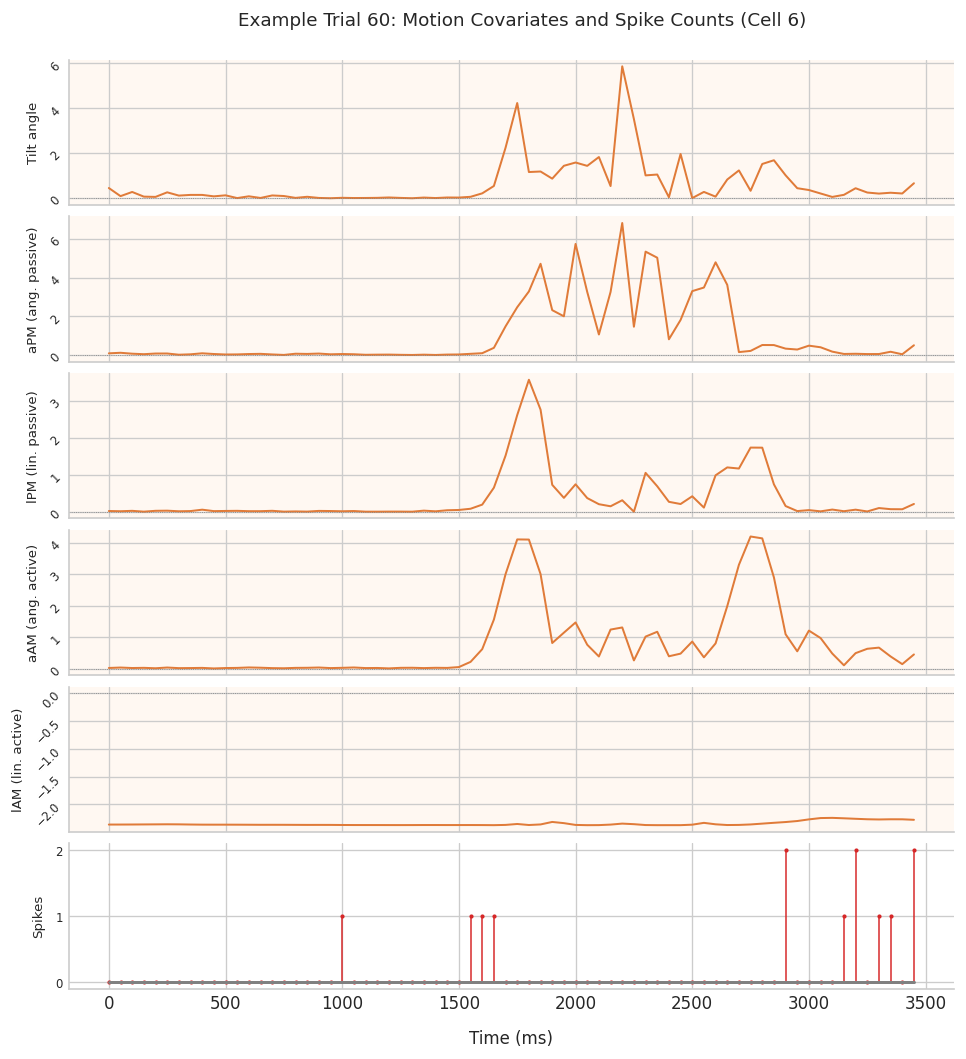

In [5]:
X, Y, cell_ids, _ = load_data("../resources/data/real/Temi_Data.mat")

fig1 = plot_covariate_trial(
    X,
    Y,
    cell_ids,
    cell_idx=6,
    trial_idx=60,
    covariate_names=COVARIATE_NAMES_REAL,
    trials_per_cell=89,
    bin_duration_ms=50,
    show_only_indices=[0, 1, 2, 3, 4],
    figsize=(9, 9),
    title="Example Trial 60: Motion Covariates and Spike Counts (Cell 6)",
)

fig1.savefig(FIG_DIR / "figure1_covariate_trial.png", dpi=300, bbox_inches="tight")
fig1.savefig(FIG_DIR / "figure1_covariate_trial.pdf", bbox_inches="tight")
print("Figure 1 saved.")
fig1

## Figure 2 — Simulated Data: Per-Cell Model Comparison

[({0: {'model': PoissonRegressor(alpha=0.1, max_iter=2000), 'scaler': None, 'train': {'pseudo_r2': 0.43148338417201193, 'log_likelihood': 11061.932737154246, 'deviance': 6.741776530354459}, 'val': {'pseudo_r2': 0.47399406283094747, 'log_likelihood': 2301.523916489691, 'deviance': 6.294654707716102}, 'test': {'pseudo_r2': 0.5114542603904411, 'log_likelihood': 3256.042453096347, 'deviance': 7.40721098125008}, 'y_pred_train': array([4.74378313, 2.19734269, 1.76849321, ..., 1.38468624, 0.44152954,
       1.20592548]), 'y_pred_val': array([ 1.53522176,  5.7812483 , 10.86301276,  5.92937545,  4.35290133,
        4.2641573 , 53.27401329,  9.53100468,  1.92888396,  3.00871362,
        1.02677984,  0.98498107,  3.71861433,  6.09891781, 11.14253543,
        8.7427029 ,  1.57292826,  1.05846033,  7.83427737,  9.06548105,
        1.18869993,  4.88043793,  0.16730551, 17.41336282, 17.05329712,
        1.32709304,  1.66781951,  1.3262201 ,  1.27673636,  1.95427078,
        2.01790914, 21.93630401,  

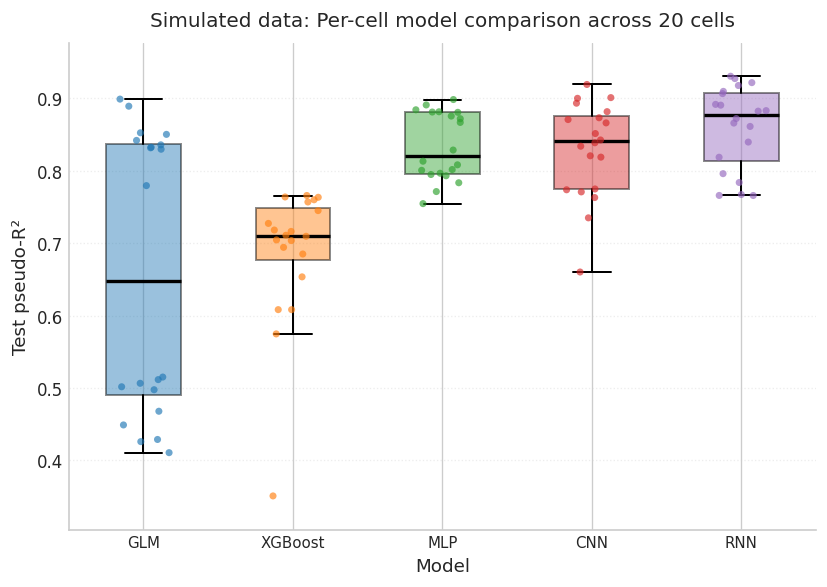

In [6]:
# Short display names for cleaner axis
PERCELL_DISPLAY = {
    "GLM": "GLM",
    "XGBoost": "XGBoost",
    "NN-PerCell-MLP": "MLP",
    "NN-PerCell-CNN": "CNN",
    "NN-PerCell-RNN": "RNN",
}

sim_percell_display = [
    (res, PERCELL_DISPLAY.get(name, name)) for res, name in sim_percell_list
]

print(sim_percell_display)

fig2 = plot_r2_comparison_boxplot(
    sim_percell_display,
    split="test",
    title="Simulated data: Per-cell model comparison across 20 cells",
    figsize=(7, 5),
    show_points=True,
    rotate_labels=False,
    chance_line=False,
)

fig2.savefig(FIG_DIR / "figure2_simulated_percell.png", dpi=300, bbox_inches="tight")
fig2.savefig(FIG_DIR / "figure2_simulated_percell.pdf", bbox_inches="tight")
print("Figure 2 saved.")
fig2

## Figure 3 — Simulated Data: Transfer Learning Architecture Comparison

Figure 3 saved.


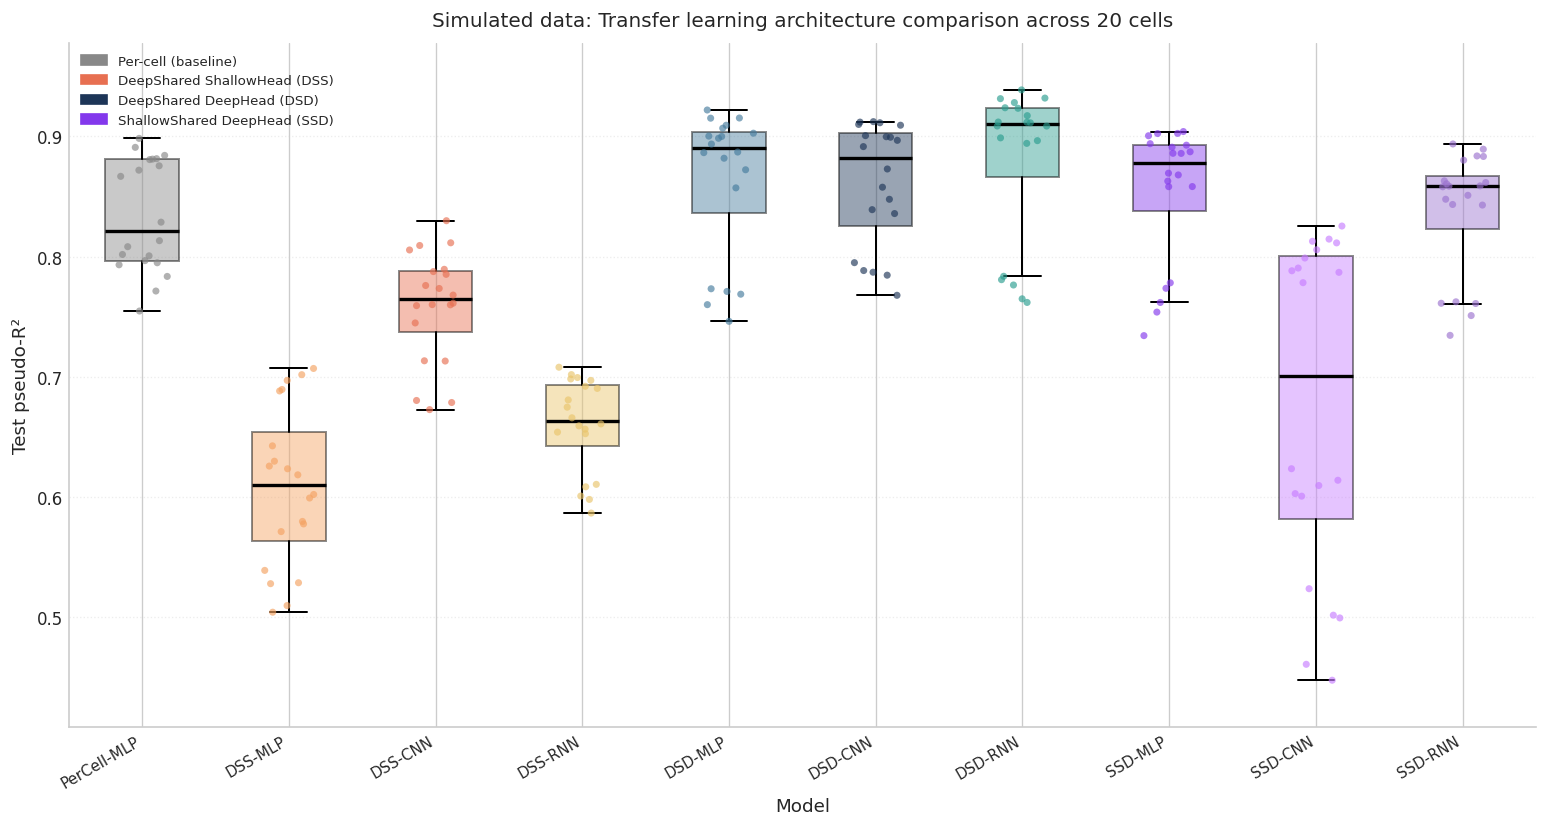

In [7]:
# Short display names for TL models
TL_DISPLAY = {
    "NN-PerCell-MLP": "PerCell-MLP",
    "NN-DeepSharedShallowHead-TL-MLP": "DSS-MLP",
    "NN-DeepSharedShallowHead-TL-CNN": "DSS-CNN",
    "NN-DeepSharedShallowHead-TL-RNN": "DSS-RNN",
    "NN-DeepSharedDeepHead-TL-MLP": "DSD-MLP",
    "NN-DeepSharedDeepHead-TL-CNN": "DSD-CNN",
    "NN-DeepSharedDeepHead-TL-RNN": "DSD-RNN",
    "NN-ShallowSharedDeepHead-TL-MLP": "SSD-MLP",
    "NN-ShallowSharedDeepHead-TL-CNN": "SSD-CNN",
    "NN-ShallowSharedDeepHead-TL-RNN": "SSD-RNN",
}

# Include per-cell MLP as baseline reference
percell_mlp = [
    (res, "PerCell-MLP") for res, name in sim_percell_list if name == "NN-PerCell-MLP"
]
sim_tl_display = percell_mlp + [
    (res, TL_DISPLAY.get(name, name)) for res, name in sim_tl_list
]

# Colour scheme: grey for baseline, grouped colours for TL families
# DSS = deep shared shallow head (orange family)
# DSD = deep shared deep head (blue family)
# SSD = shallow shared deep head (green family)
sim_tl_colours = [
    "#888888",  # PerCell-MLP (grey baseline)
    "#F4A261",
    "#E76F51",
    "#E9C46A",  # DSS: MLP, CNN, RNN
    "#457B9D",
    "#1D3557",
    "#2A9D8F",  # DSD: MLP, CNN, RNN
    "#8338EC",
    "#C77DFF",
    "#9B72CF",  # SSD: MLP, CNN, RNN
]

fig3 = plot_r2_comparison_boxplot(
    sim_tl_display,
    split="test",
    title="Simulated data: Transfer learning architecture comparison across 20 cells",
    figsize=(13, 7),
    show_points=True,
    rotate_labels=True,
    color_palette=sim_tl_colours,
)

# Add architecture family legend
ax3 = fig3.axes[0]
legend_patches = [
    mpatches.Patch(color="#888888", label="Per-cell (baseline)"),
    mpatches.Patch(color="#E76F51", label="DeepShared ShallowHead (DSS)"),
    mpatches.Patch(color="#1D3557", label="DeepShared DeepHead (DSD)"),
    mpatches.Patch(color="#8338EC", label="ShallowShared DeepHead (SSD)"),
]
ax3.legend(handles=legend_patches, fontsize=8, loc="upper left")

fig3.savefig(FIG_DIR / "figure3_simulated_tl.png", dpi=300, bbox_inches="tight")
fig3.savefig(FIG_DIR / "figure3_simulated_tl.pdf", bbox_inches="tight")
print("Figure 3 saved.")
fig3

## Figure 4 — Real Data: Full Model Comparison (100 cells)

Figure 4 saved.


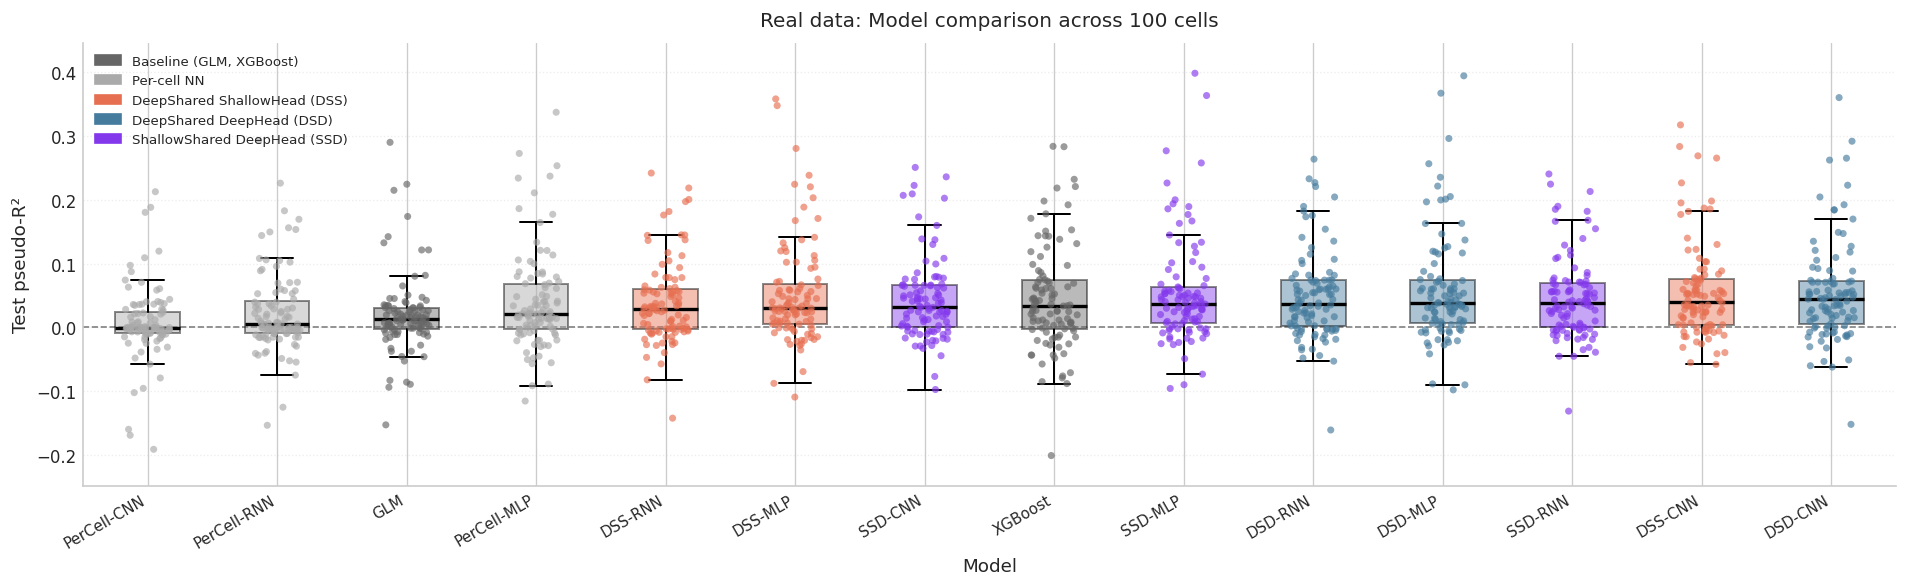

In [8]:
# Clean display names for all 14 real models
REAL_DISPLAY = {
    "GLM": "GLM",
    "XGBoost": "XGBoost",
    "NN-PerCell-CNN": "PerCell-CNN",
    "NN-PerCell-RNN": "PerCell-RNN",
    "NN-PerCell-MLP": "PerCell-MLP",
    "NN-DeepSharedShallowHead-TL-RNN": "DSS-RNN",
    "NN-DeepSharedShallowHead-TL-MLP": "DSS-MLP",
    "NN-ShallowSharedDeepHead-TL-CNN": "SSD-CNN",
    "NN-DeepSharedDeepHead-TL-RNN": "DSD-RNN",
    "NN-ShallowSharedDeepHead-TL-MLP": "SSD-MLP",
    "NN-ShallowSharedDeepHead-TL-RNN": "SSD-RNN",
    "NN-DeepSharedDeepHead-TL-MLP": "DSD-MLP",
    "NN-DeepSharedShallowHead-TL-CNN": "DSS-CNN",
    "NN-DeepSharedDeepHead-TL-CNN": "DSD-CNN",
}

real_display_list = [
    (res, REAL_DISPLAY.get(name, name))
    for res, name in real_all_list  # already sorted by median
]

# Colour scheme: baselines grey/brown, TL families in colour
real_colours = []
for _, name in real_display_list:
    if name in ("GLM", "XGBoost"):
        real_colours.append("#666666")
    elif name.startswith("PerCell"):
        real_colours.append("#AAAAAA")
    elif name.startswith("DSS"):
        real_colours.append("#E76F51")
    elif name.startswith("DSD"):
        real_colours.append("#457B9D")
    elif name.startswith("SSD"):
        real_colours.append("#8338EC")
    else:
        real_colours.append("#999999")

fig4 = plot_r2_comparison_boxplot(
    real_display_list,
    split="test",
    title="Real data: Model comparison across 100 cells",
    figsize=(16, 5),
    show_points=True,
    rotate_labels=True,
    color_palette=real_colours,
)

# Add family legend
ax4 = fig4.axes[0]
legend_patches = [
    mpatches.Patch(color="#666666", label="Baseline (GLM, XGBoost)"),
    mpatches.Patch(color="#AAAAAA", label="Per-cell NN"),
    mpatches.Patch(color="#E76F51", label="DeepShared ShallowHead (DSS)"),
    mpatches.Patch(color="#457B9D", label="DeepShared DeepHead (DSD)"),
    mpatches.Patch(color="#8338EC", label="ShallowShared DeepHead (SSD)"),
]
ax4.legend(handles=legend_patches, fontsize=8, loc="upper left")

fig4.savefig(
    FIG_DIR / "figure4_real_model_comparison.png", dpi=300, bbox_inches="tight"
)
fig4.savefig(FIG_DIR / "figure4_real_model_comparison.pdf", bbox_inches="tight")
print("Figure 4 saved.")
fig4

## Figure 5 — Pairwise Scatter: Best TL Model vs GLM, Coloured by Batch

Best model = TL-DeepSharedDeepHead-CNN (median pR² = 0.044, 79% above chance)

Cells with both GLM and NN-DeepSharedDeepHead-TL-CNN: 100
Figure 5 saved. 76% of cells improved by TL over GLM.


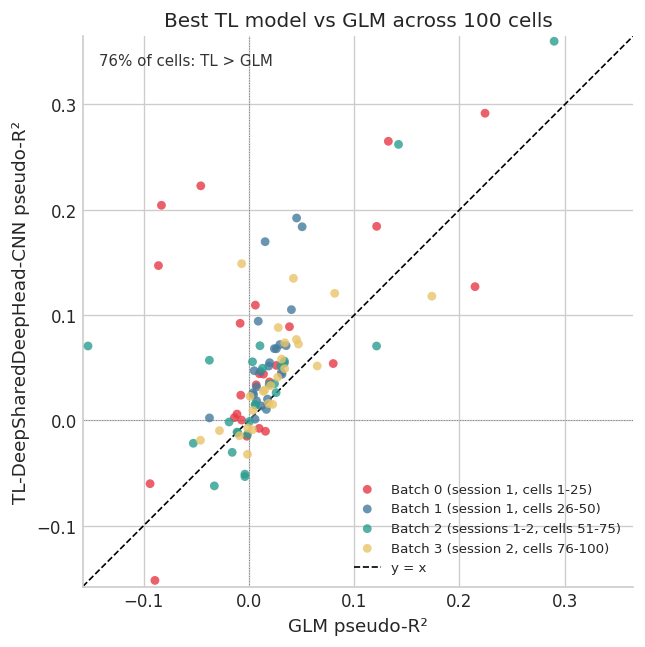

In [9]:
# Load the batch column — need cell-to-batch mapping
# Batches: 0 = cells 1-25, 1 = cells 26-50, 2 = cells 51-75, 3 = cells 76-100
def cell_to_batch(cell_id):
    if 1 <= cell_id <= 25:
        return 0
    if 26 <= cell_id <= 50:
        return 1
    if 51 <= cell_id <= 75:
        return 2
    if 76 <= cell_id <= 100:
        return 3
    return -1


# Extract GLM and best TL model pR2 per cell
BEST_TL = "NN-DeepSharedDeepHead-TL-CNN"

cells_common = df_all["cell"].astype(int).tolist()
print(f"Cells with both GLM and {BEST_TL}: {len(cells_common)}")
r2_glm = df_all["GLM"].values
r2_tl = df_all[BEST_TL].values
batches = np.array([cell_to_batch(c) for c in cells_common])

# Batch colours and session labels
BATCH_COLOURS = ["#E63946", "#457B9D", "#2A9D8F", "#E9C46A"]
BATCH_LABELS = [
    "Batch 0 (session 1, cells 1-25)",
    "Batch 1 (session 1, cells 26-50)",
    "Batch 2 (sessions 1-2, cells 51-75)",
    "Batch 3 (session 2, cells 76-100)",
]

_set_journal_style()
fig5, ax5 = plt.subplots(figsize=(5.5, 5.5))

for b in range(4):
    mask = batches == b
    ax5.scatter(
        r2_glm[mask],
        r2_tl[mask],
        color=BATCH_COLOURS[b],
        label=BATCH_LABELS[b],
        alpha=0.8,
        s=28,
        edgecolors="none",
        zorder=3,
    )

# Unity line (y = x)
lim_min = min(r2_glm.min(), r2_tl.min()) - 0.005
lim_max = max(r2_glm.max(), r2_tl.max()) + 0.005
ax5.plot(
    [lim_min, lim_max], [lim_min, lim_max], "k--", linewidth=1, zorder=1, label="y = x"
)

# Chance lines
ax5.axhline(0, color="gray", linewidth=0.6, linestyle=":", zorder=1)
ax5.axvline(0, color="gray", linewidth=0.6, linestyle=":", zorder=1)

# Fraction of cells where TL > GLM
pct_improved = 100 * np.mean(r2_tl > r2_glm)
ax5.text(
    0.03,
    0.97,
    f"{pct_improved:.0f}% of cells: TL > GLM",
    transform=ax5.transAxes,
    fontsize=9,
    va="top",
    ha="left",
    color="#333333",
)

ax5.set_xlabel("GLM pseudo-R²", fontsize=11)
ax5.set_ylabel("TL-DeepSharedDeepHead-CNN pseudo-R²", fontsize=11)
ax5.set_title("Best TL model vs GLM across 100 cells", fontsize=12)
ax5.set_xlim(lim_min, lim_max)
ax5.set_ylim(lim_min, lim_max)
ax5.set_aspect("equal", adjustable="box")
ax5.legend(fontsize=8, loc="lower right")

fig5.tight_layout()
fig5.savefig(FIG_DIR / "figure5_pairwise_scatter.png", dpi=300, bbox_inches="tight")
fig5.savefig(FIG_DIR / "figure5_pairwise_scatter.pdf", bbox_inches="tight")
plt.close(fig5)
print(f"Figure 5 saved. {pct_improved:.0f}% of cells improved by TL over GLM.")
fig5

## Summary

In [10]:
print("All figures saved to:", FIG_DIR.resolve())
for p in sorted(FIG_DIR.glob("figure*.png")):
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name:50s}  {size_kb:.0f} KB")

All figures saved to: C:\Users\Temitope Shitta\BioInfo Projects\BIOL61230_poisson_neural_net\resources\results\figures
  figure1_covariate_trial.png                         288 KB
  figure2_simulated_percell.png                       113 KB
  figure3_simulated_tl.png                            264 KB
  figure4_real_model_comparison.png                   582 KB
  figure5_pairwise_scatter.png                        180 KB
